# LIBRARIES AND DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_csv(r"C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\superstore sales\data\superstore.csv", encoding="latin-1")

In [3]:
print("Shape sales:", df.shape)
df.info()                                                       # data types and null values
df.describe()                                                   # basic statistics


Shape sales: (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
#Key columns
for col in ['Category', 'Region', 'Segment']:
    print(f"\n{col} unique values:")
    print(df[col].unique())


Category unique values:
['Furniture' 'Office Supplies' 'Technology']

Region unique values:
['South' 'West' 'Central' 'East']

Segment unique values:
['Consumer' 'Corporate' 'Home Office']


# EDA

## Sales, profit and profit margin

### By Year

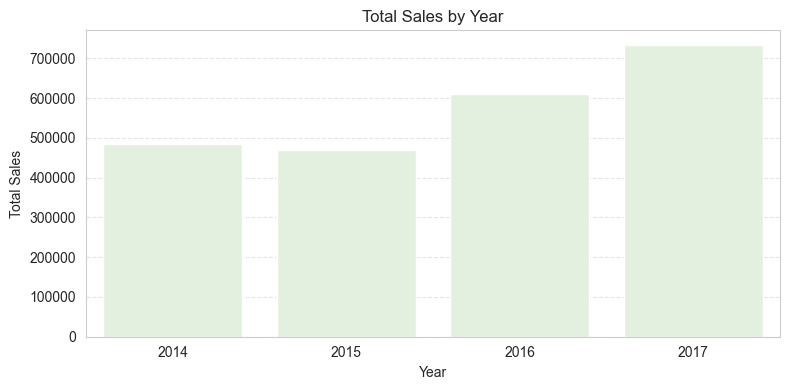

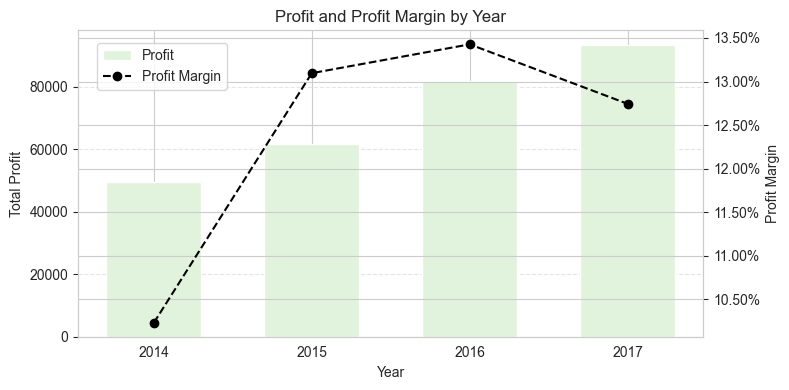

In [21]:
# Ensure Year is numeric and sorted, and compute Profit Margin safely
yearly = (df.assign(**{
                "Order Date": pd.to_datetime(df["Order Date"], errors="coerce"),
                "Year": pd.to_datetime(df["Order Date"], errors="coerce").dt.year
           })
           .groupby("Year", as_index=False)
           .agg(Sales=("Sales", "sum"),
                Profit=("Profit", "sum"))
         )
yearly = yearly.sort_values("Year")
yearly["Profit Margin"] = yearly["Profit"] / yearly["Sales"]
yearly["Profit Margin"] = yearly["Profit Margin"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Sales by Year (bar plot)
plt.figure(figsize=(8, 4))
sns.barplot(data=yearly, x="Year", y="Sales")
plt.title("Total Sales by Year")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# X positions and colors (consistent green tones)
years = yearly["Year"].to_numpy()
x = np.arange(len(years))
width = 0.6

fig, ax = plt.subplots(figsize=(8, 4))

# Bars: Profit by Year
bars = ax.bar(x, yearly["Profit"].to_numpy(), width, label="Profit")

# Secondary axis: Profit Margin line
ax2 = ax.twinx()
line = ax2.plot(x,
                yearly["Profit Margin"].to_numpy(),
                linestyle="--",
                color="black",
                marker="o",
                label="Profit Margin")

# Axes labels and title
ax.set_title("Profit and Profit Margin by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Profit")
ax2.set_ylabel("Profit Margin")

# X ticks as year labels
ax.set_xticks(x)
ax.set_xticklabels(years)

# Grid on primary y-axis only
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Percent format on the secondary y-axis
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# Combined legend (bars + line)
handles = [bars] + line
labels = ["Profit", "Profit Margin"]
ax2.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
plt.show()

### By Category

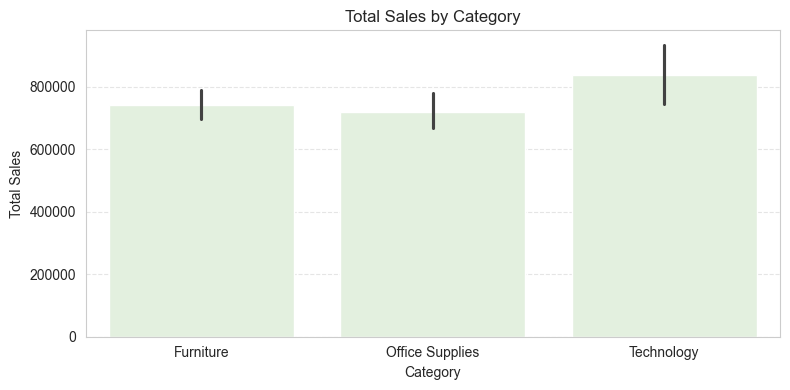

In [11]:
# Sales
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Category", y="Sales", estimator=np.sum)
plt.title("Total Sales by Category")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

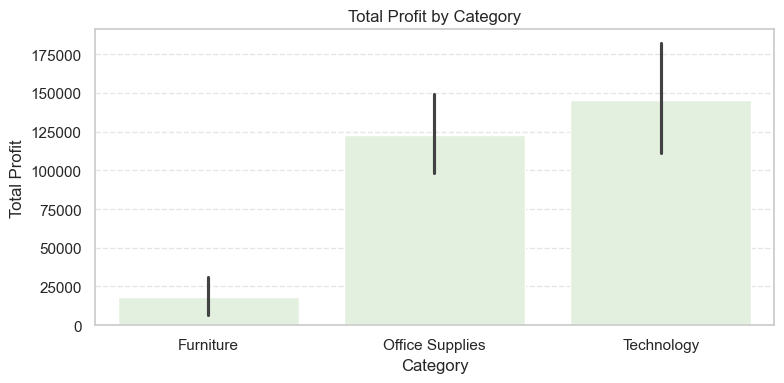

In [49]:
# Profit
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Category", y="Profit", estimator=np.sum)
plt.title("Total Profit by Category")
plt.ylabel("Total Profit")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

          Category       Profit        Sales  Profit_Ratio
0        Furniture   18451.2728  741999.7953      0.024867
1  Office Supplies  122490.8008  719047.0320      0.170352
2       Technology  145454.9481  836154.0330      0.173957


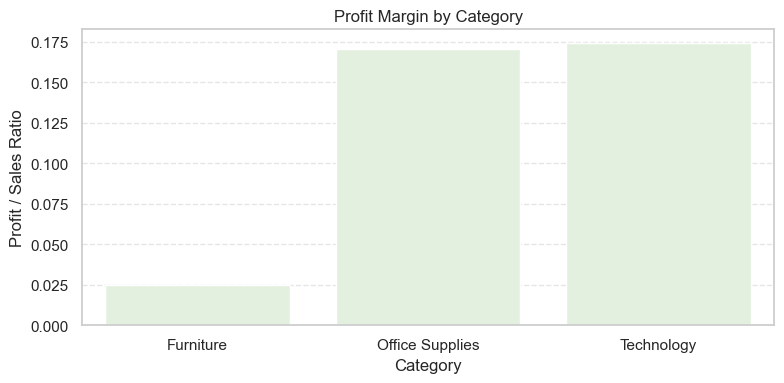

In [40]:
# Profit margin 

# Compute total profit and sales per category
category_profit = (
    df.groupby("Category", as_index=False)
      .agg({"Profit": "sum", "Sales": "sum"})
)

# Create a new column for profit margin (profitability ratio)
category_profit["Profit_Ratio"] = category_profit["Profit"] / category_profit["Sales"]

print(category_profit)

plt.figure(figsize=(8,4))
sns.barplot(data=category_profit, x="Category", y="Profit_Ratio", estimator=np.sum)
plt.title("Profit Margin by Category")
plt.ylabel("Profit / Sales Ratio")
plt.xlabel("Category")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### By Region

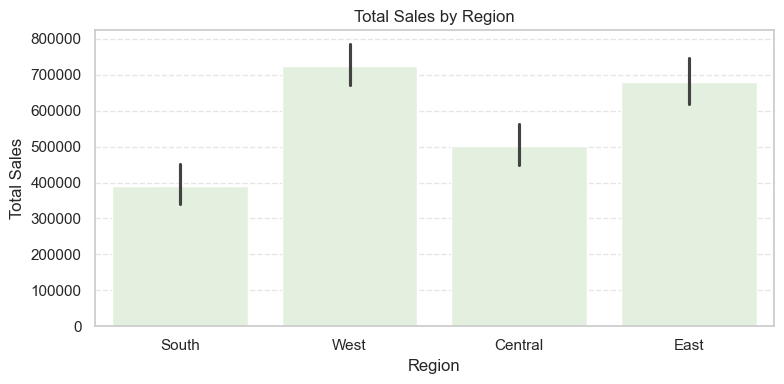

In [50]:
# Sales
sns.set_palette("Greens")

plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Region", y="Sales", estimator=np.sum)
plt.title("Total Sales by Region")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

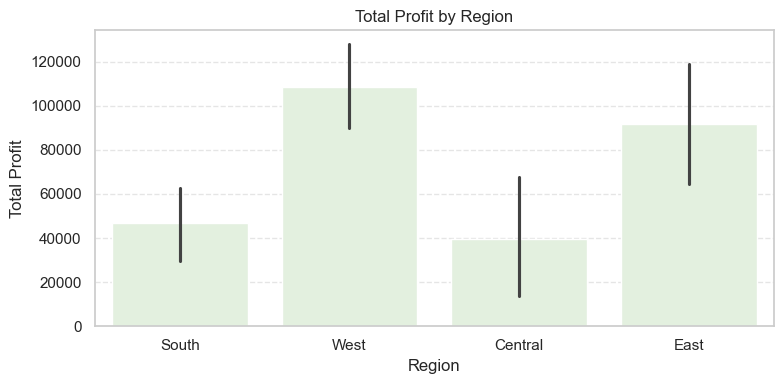

In [51]:
# Profit
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Region", y="Profit", estimator=np.sum)
plt.title("Total Profit by Region")
plt.ylabel("Total Profit")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

    Region       Profit        Sales  Profit_Ratio
0  Central   39706.3625  501239.8908      0.079216
1     East   91522.7800  678781.2400      0.134834
2    South   46749.4303  391721.9050      0.119343
3     West  108418.4489  725457.8245      0.149448


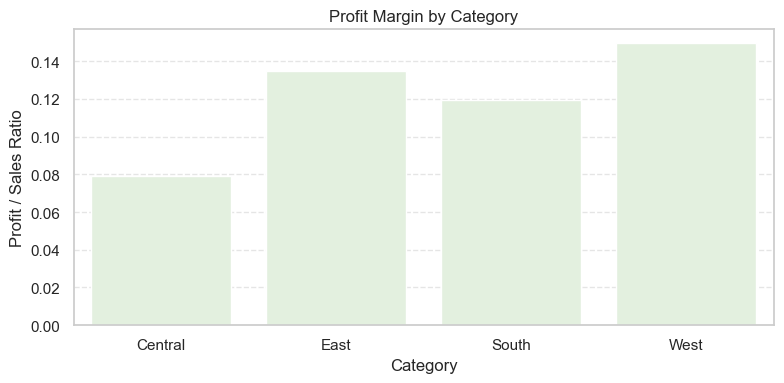

In [54]:
# Profit margin 

# Compute total profit and sales per category
category_profit = (
    df.groupby("Region", as_index=False)
      .agg({"Profit": "sum", "Sales": "sum"})
)

# Create a new column for profit margin (profitability ratio)
category_profit["Profit_Ratio"] = category_profit["Profit"] / category_profit["Sales"]

print(category_profit)

plt.figure(figsize=(8,4))
sns.barplot(data=category_profit, x="Region", y="Profit_Ratio", estimator=np.sum)
plt.title("Profit Margin by Category")
plt.ylabel("Profit / Sales Ratio")
plt.xlabel("Category")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### By Segment

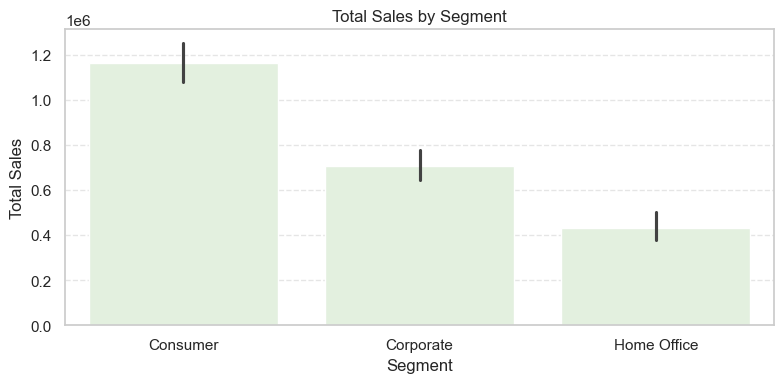

In [56]:
# Sales
sns.set_palette("Greens")

plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Segment", y="Sales", estimator=np.sum)
plt.title("Total Sales by Segment")
plt.ylabel("Total Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

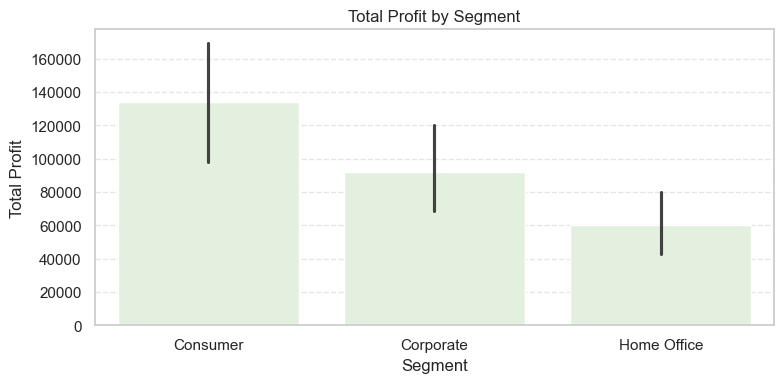

In [57]:
# Profit
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Segment", y="Profit", estimator=np.sum)
plt.title("Total Profit by Segment")
plt.ylabel("Total Profit")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

       Segment       Profit         Sales  Profit_Ratio
0     Consumer  134119.2092  1.161401e+06      0.115481
1    Corporate   91979.1340  7.061464e+05      0.130255
2  Home Office   60298.6785  4.296531e+05      0.140343


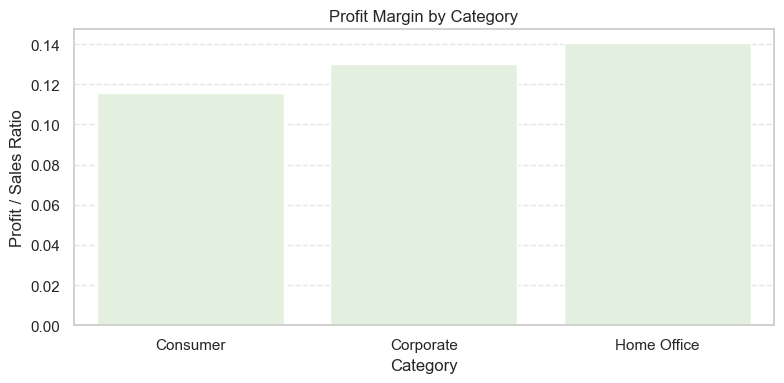

In [59]:
# Profit margin 

# Compute total profit and sales per category
category_profit = (
    df.groupby("Segment", as_index=False)
      .agg({"Profit": "sum", "Sales": "sum"})
)

# Create a new column for profit margin (profitability ratio)
category_profit["Profit_Ratio"] = category_profit["Profit"] / category_profit["Sales"]

print(category_profit)

plt.figure(figsize=(8,4))
sns.barplot(data=category_profit, x="Segment", y="Profit_Ratio", estimator=np.sum)
plt.title("Profit Margin by Category")
plt.ylabel("Profit / Sales Ratio")
plt.xlabel("Category")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Profitability and Average Discount by Category

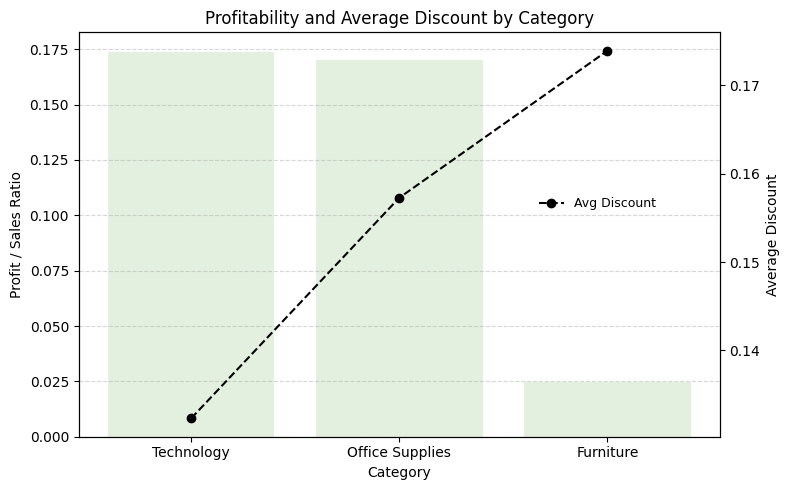

In [ ]:
# Group by Category to summarize key business metrics
cat_summary = (
    df.groupby("Category", as_index=False)
      .agg(Sales=("Sales", "sum"),
           Profit=("Profit", "sum"),
           Avg_Discount=("Discount", "mean"))
)

# Compute profit ratio (profitability)
cat_summary["Profit_Ratio"] = cat_summary["Profit"] / cat_summary["Sales"]

# Sort by profitability for clearer visualization
cat_summary = cat_summary.sort_values("Profit_Ratio", ascending=False)

# --- Create figure ---
plt.figure(figsize=(8,5))

# Bar plot: total profit
sns.barplot(data=cat_summary, x="Category", y="Profit_Ratio")

# Line plot (second axis): average discount
ax = plt.gca()
ax2 = ax.twinx()
ax2.plot(cat_summary["Category"], cat_summary["Avg_Discount"], color="black", marker="o", linestyle="--", label="Avg Discount")

# Titles and labels
ax.set_title("Profitability and Average Discount by Category")
ax.set_ylabel("Profit / Sales Ratio")
ax2.set_ylabel("Average Discount", color="black")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()

# Legend (bottom-right, same style as previous charts)
bar_handles, bar_labels = ax.get_legend_handles_labels()
line_handles, line_labels = ax2.get_legend_handles_labels()

ax2.legend(
    line_handles,
    line_labels,
    loc="upper left",
    bbox_to_anchor=(0.70, 0.62),
    fontsize=9,
    frameon=False
)

plt.show()

Conclusions:                                                                                                                                                     
i) Technology and Office Supplies sustain overall profit.

ii) Furniture generates high volume but low margins, with losses in specific subcategories.

iii) The average discount of 26% on Tables is probably too high → opportunity to optimise discount policy.

iv) The main problem is Furniture; neither the regional nor the segment analysis reveal any major complications.

## Furniture analysis

Since ‘furniture’ has excessively low profit margins despite having a good number of sales, we are going to analyse the cause of this low performance.

### Furniture by Sub-Category

  Sub-Category        Sales      Profit  Avg_Discount  Orders  Profit_Ratio
3       Tables  206965.5320 -17725.4811      0.261285     319     -0.085645
0    Bookcases  114879.9963  -3472.5560      0.211140     228     -0.030228
1       Chairs  328449.1030  26590.1663      0.170178     617      0.080957
2  Furnishings   91705.1640  13059.1436      0.138349     957      0.142404


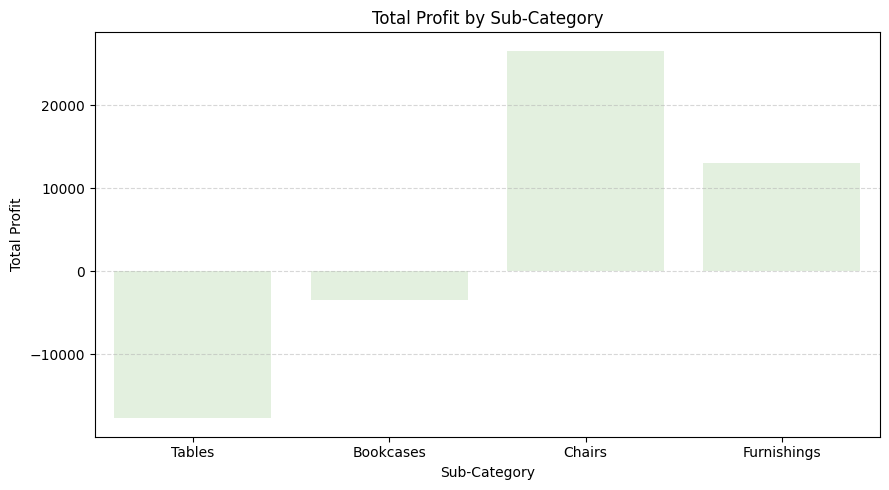

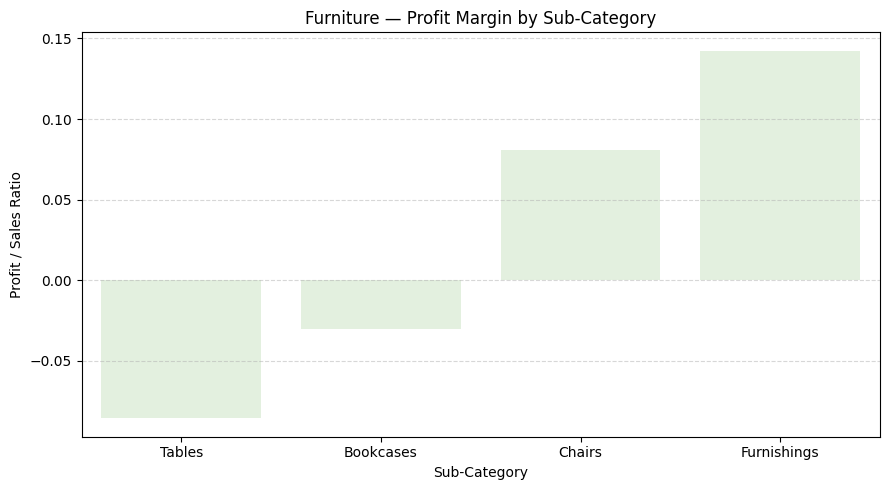

In [14]:
# 1) Build a subcategory summary restricted to Furniture
furn = df[df["Category"] == "Furniture"].copy()

furn_sub = (
    furn.groupby("Sub-Category", as_index=False)
        .agg(Sales=("Sales", "sum"),
             Profit=("Profit", "sum"),
             Avg_Discount=("Discount", "mean"),
             Orders=("Sales", "count"))
)
furn_sub["Profit_Ratio"] = furn_sub["Profit"] / furn_sub["Sales"]

# 2) Sort by margin to see the weakest/strongest subcategories
furn_sub = furn_sub.sort_values("Profit_Ratio")

print(furn_sub)

# 3) Plot: profit by subcategory (Furniture only)
plt.figure(figsize=(9,5))
sns.barplot(data=furn_sub, x="Sub-Category", y="Profit", estimator=np.sum)
plt.title("Total Profit by Sub-Category")
plt.ylabel("Total Profit")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# 4) Plot: profit margin by subcategory (Furniture only)
plt.figure(figsize=(9,5))
sns.barplot(data=furn_sub, x="Sub-Category", y="Profit_Ratio", errorbar=None)
plt.title("Furniture — Profit Margin by Sub-Category")
plt.ylabel("Profit / Sales Ratio")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Furniture by segment

In [ ]:
# Group by segment: compute total sales, total profit, and average discount
furn_segment = (
    furn.groupby("Segment", as_index=False)
        .agg(Sales=("Sales", "sum"),
             Profit=("Profit", "sum"),
             Avg_Discount=("Discount", "mean"))
)

# Calculate profit ratio
furn_segment["Profit_Ratio"] = furn_segment["Profit"] / furn_segment["Sales"]

furn_segment

,Segment,Sales,Profit,Avg_Discount,Profit_Ratio
0,Consumer,391049.3120,6991.0786,0.176739,0.017878
1,Corporate,229019.7858,7584.8158,0.174071,0.033119
2,Home Office,121930.6975,3875.3784,0.165000,0.031783


### Furniture subcategories by segment

In [ ]:
# Group by Segment and Sub-Category
furn_seg_sub = (
    furn.groupby(["Segment", "Sub-Category"], as_index=False)
        .agg(Sales=("Sales", "sum"),
             Profit=("Profit", "sum"),
             Avg_Discount=("Discount", "mean"))
)

# Profitability ratio
furn_seg_sub["Profit_Ratio"] = furn_seg_sub["Profit"] / furn_seg_sub["Sales"]

# Show the rows with losses (negative Profit), sorted by worst first
losses = furn_seg_sub[furn_seg_sub["Profit"] < 0].sort_values("Profit")

losses

,Segment,Sub-Category,Sales,Profit,Avg_Discount,Profit_Ratio
3,Consumer,Tables,99933.7950,-9728.0378,0.266038,-0.097345
7,Corporate,Tables,70871.7175,-4906.4986,0.259906,-0.069231
0,Consumer,Bookcases,68632.7290,-4435.6382,0.221450,-0.064629
11,Home Office,Tables,36160.0195,-3090.9447,0.250000,-0.085480


In [18]:
# Group by Region and Sub-Category
furn_reg_sub = (
    furn.groupby(["Region", "Sub-Category"], as_index=False)
        .agg(Sales=("Sales", "sum"),
             Profit=("Profit", "sum"),
             Avg_Discount=("Discount", "mean"))
)

# Profitability ratio
furn_reg_sub["Profit_Ratio"] = furn_reg_sub["Profit"] / furn_reg_sub["Sales"]

# Show the rows with losses (negative Profit), sorted by worst first
losses = furn_reg_sub[furn_reg_sub["Profit"] < 0].sort_values("Profit")

losses

,Region,Sub-Category,Sales,Profit,Avg_Discount,Profit_Ratio
7,East,Tables,39139.8070,-11025.3801,0.373750,-0.281692
11,South,Tables,43916.1920,-4623.0579,0.222549,-0.105270
2,Central,Furnishings,15254.3700,-3906.2168,0.403902,-0.256072
3,Central,Tables,39154.9710,-3559.6504,0.262500,-0.090912
0,Central,Bookcases,24157.1768,-1997.9043,0.232800,-0.082704
12,West,Bookcases,36004.1235,-1646.5117,0.228750,-0.045731
4,East,Bookcases,43819.3340,-1167.6318,0.220000,-0.026646


In [ ]:
# Group by Segment and Sub-Category
furn_seg_sub = (
    furn.groupby(["Segment", "Sub-Category"], as_index=False)
        .agg(Sales=("Sales", "sum"),
             Profit=("Profit", "sum"),
             Avg_Discount=("Discount", "mean"))
)

### Furniture Profit and Avg Discount by Segment and Sub-Category

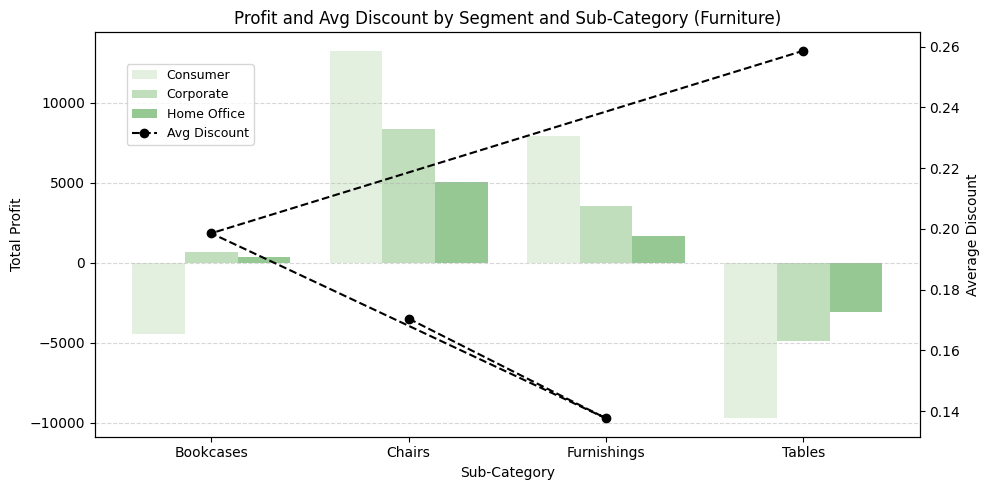

In [ ]:
# Sort subcategories to keep visual consistency
order = furn_seg_sub.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).index

# Create figure
plt.figure(figsize=(10,5))

# Bar plot for Profit
sns.barplot(
    data=furn_seg_sub,
    x="Sub-Category",
    y="Profit",
    hue="Segment",
    estimator=np.sum,
    errorbar=None
)

# Remove Seaborn's default legend 
plt.legend([],[], frameon=False)

# Overlay a line for average discount (scaled)
avg_discount = furn_seg_sub.groupby("Sub-Category")["Avg_Discount"].mean().reindex(order)

# Create secondary y-axis for discount
ax = plt.gca()
ax2 = ax.twinx()

# Plot line on the secondary axis
ax2.plot(order, avg_discount.values, color="black", marker="o", linestyle="--", label="Avg Discount")

# Axis labels and formatting
ax.set_title("Profit and Avg Discount by Segment and Sub-Category (Furniture)")
ax.set_ylabel("Total Profit")
ax2.set_ylabel("Average Discount", color="black")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")s
plt.tight_layout()

# Legend configuration (merge both axes)
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Place legend in the lower right corner, slightly inside the plot
ax2.legend(
    lines + lines2,
    labels + labels2,
    loc="lower right",                     # anchor reference corner
    bbox_to_anchor=(0.2, 0.706),           # move a bit up from the bottom-right
    fontsize=9,
)

plt.show()

Analysis

The visualization shows how profitability within the Furniture category varies across both segments and sub-categories.
Despite steady sales volumes, several groups — especially Tables and Bookcases — generate notable losses, mainly due to high discount levels.
In contrast, the Corporate and Home Office segments show slightly better margins, suggesting more controlled discounting policies or different purchasing behaviors.

Overall, this analysis highlights that Furniture profitability issues are less about regional performance and more linked to pricing strategy and customer segmentation.